In [1]:
#pip install pandas networkx numpy matplotlib seaborn
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_posts = pd.read_csv('all_posts_active_subreddit.csv')

In [3]:
df_posts.head(2)

,Unnamed: 0,Post ID,Title,Type,Content,Author,Upvotes,Downvotes,Upvote Ratio,Comments,Date & Time,External Link,category,Subreddit
0,0,1996ooq,What is 'new denial?' An alarming wave of clim...,URL,https://www.cnn.com/2024/01/16/climate/climate...,Alexius08,4.0,0.0,0.84,0.0,2024-01-17 20:23:39,https://www.cnn.com/2024/01/16/climate/climate...,hot,FridaysForFuture
1,1,1903h8r,Canadian judges agree that Canada does indeed ...,URL,https://www.cbc.ca/kidsnews/post/fight-continu...,IntrepidGentian,10.0,0.0,1.00,0.0,2024-01-06 16:19:42,https://www.cbc.ca/kidsnews/post/fight-continu...,hot,FridaysForFuture


In [4]:
df_com = pd.read_csv('all_comments.csv')
df_com.head(2)

,Comment ID,Parent ID,Content,Author,Upvotes,Downvotes,Date & Time,Score,Post ID,Permalink
0,kfz0n9j,NaN,Placing a comment so I can find this again later,MarcoYTVA,1.0,0.0,2024-01-02 13:11:49,1.0,18w60ix,NaN
1,kdkrem6,NaN,"""For three decades, policymakers have promised...",tkonicz,1.0,0.0,2023-12-16 05:44:11,1.0,18jkfbc,NaN


In [5]:
df_posts.groupby(['Subreddit'])['Post ID'].nunique().reset_index(name='posts')

,Subreddit,posts
0,ClimateActionPlan,1613
1,ClimateCO,1024
2,ClimateCrisisCanada,1500
3,ClimateNews,1352
4,ClimateOffensive,1965
5,ClimateShitposting,1145
6,Climate_Nuremberg,104
7,Ecologisme,1295
8,ExtinctionRebellion,1822
9,FridaysForFuture,930


In [6]:
df = df_com.merge(df_posts[['Post ID', 'Subreddit']].drop_duplicates(), on='Post ID', how='left')

# Ensure that 'Parent ID' is not NA to keep only comments that have a parent (either a post or another comment)
df = df.dropna(subset=['Parent ID'])

# Merge the DataFrame with itself to align comments with their replies, including Subreddit information
df_replies = pd.merge(df, df, left_on="Comment ID", right_on="Parent ID", suffixes=('_1', '_2'))

# Filter out rows where Author_1 == Author_2 to get only cases where different authors are interacting
df_replies_filtered = df_replies[df_replies['Author_1'] != df_replies['Author_2']]

# Selecting relevant columns for the output DataFrame, including Subreddit from either side (they should be the same)
df_author_interaction = df_replies_filtered[['Author_1', 'Author_2', 'Post ID_1', 'Date & Time_2', 'Subreddit_1']].drop_duplicates()

# Renaming columns for clarity
df_author_interaction.rename(columns={"Post ID_1": "Post ID", "Date & Time_2": "Date & Time", "Subreddit_1": "Subreddit"}, inplace=True)

# Adding the 'Type' column to indicate these are comments
df_author_interaction['Type'] = 'Comment'

# Display the updated DataFrame
df_author_interaction


,Author_1,Author_2,Post ID,Date & Time,Subreddit,Type
0,energy4a11,jay_jay_abrahams,18eyzms,2023-12-11 08:16:53,FridaysForFuture,Comment
1,energy4a11,Ok-Possibility-9733,18eyzms,2023-12-11 23:15:52,FridaysForFuture,Comment
2,whiteandyellowcat,Dave37,183vkb5,2023-11-26 23:31:48,FridaysForFuture,Comment
3,Dave37,whiteandyellowcat,183vkb5,2023-11-26 23:42:45,FridaysForFuture,Comment
4,Dave37,squidguy_mc,17xso8b,2023-11-19 11:59:01,FridaysForFuture,Comment
...,...,...,...,...,...,...
155850,GenericOfficeMan,_JohnJacob,tf0tj6,2022-03-18 00:27:01,ClimateCrisisCanada,Comment
155851,_JohnJacob,GenericOfficeMan,tf0tj6,2022-03-18 06:04:49,ClimateCrisisCanada,Comment
155852,GenericOfficeMan,_JohnJacob,tf0tj6,2022-03-18 20:13:00,ClimateCrisisCanada,Comment
155853,_JohnJacob,GenericOfficeMan,tf0tj6,2022-03-18 21:12:11,ClimateCrisisCanada,Comment


In [7]:
df_author_interaction.groupby(['Post ID']).size().reset_index(name='nb comments').sort_values(by='nb comments',ascending=False).head(10)

,Post ID,nb comments
5569,dyzk6v,168
2247,16y3kma,161
3040,1831vlb,160
3141,1876u8n,151
8993,yxs8rp,149
3004,181i90d,146
2898,17xmqqe,143
602,12s67hk,141
6351,gh85h7,141
1663,163bz0a,140


In [8]:
df_author_interaction[['Author_1','Author_2','Post ID']].duplicated(keep=False).sum()


72859

In [9]:
df_posts.head(1)

,Unnamed: 0,Post ID,Title,Type,Content,Author,Upvotes,Downvotes,Upvote Ratio,Comments,Date & Time,External Link,category,Subreddit
0,0,1996ooq,What is 'new denial?' An alarming wave of clim...,URL,https://www.cnn.com/2024/01/16/climate/climate...,Alexius08,4.0,0.0,0.84,0.0,2024-01-17 20:23:39,https://www.cnn.com/2024/01/16/climate/climate...,hot,FridaysForFuture


In [10]:
df_direct_comments = df_com[df_com["Parent ID"].isnull()]

df_author_post_comment = pd.merge(df_direct_comments, df_posts, left_on="Post ID", right_on="Post ID", suffixes=('_comment', '_post'))

# Selecting relevant columns for the output DataFrame: Author_post, Author_comment, Post ID, and Date & Time of the post
df_author_interaction_posts = df_author_post_comment[['Author_post', 'Author_comment', 'Post ID', 'Date & Time_post','Subreddit']].drop_duplicates()

# Renaming columns for clarity
df_author_interaction_posts.rename(columns={
    "Author_post": "Author_1", 
    "Author_comment": "Author_2", 
    "Date & Time_post": "Date & Time"
}, inplace=True)

# Adding the 'Type' column to indicate these are posts
df_author_interaction_posts['Type'] = 'Post'

# Display the updated DataFrame
df_author_interaction_posts

,Author_1,Author_2,Post ID,Date & Time,Subreddit,Type
0,Polyhedral_Media,MarcoYTVA,18w60ix,2024-01-01 20:36:33,FridaysForFuture,Post
1,tkonicz,tkonicz,18jkfbc,2023-12-16 05:43:59,FridaysForFuture,Post
2,Monsteristbeste,tkonicz,18j3b0a,2023-12-15 15:58:11,FridaysForFuture,Post
3,AccomplishedHotel383,Sendboobpics_please,18frxi8,2023-12-11 10:54:23,FridaysForFuture,Post
4,AccomplishedHotel383,new_skool_hepcat,18frxi8,2023-12-11 10:54:23,FridaysForFuture,Post
...,...,...,...,...,...,...
108951,idspispopd,_JohnJacob,tf0tj6,2022-03-15 21:27:08,ClimateCrisisCanada,Post
108952,AAASA-Concentrate98X,rodinsbusiness,161pikv,2023-08-26 08:33:08,ecologie,Post
108953,AAASA-Concentrate98X,Frog-4724,161pikv,2023-08-26 08:33:08,ecologie,Post
108954,AAASA-Concentrate98X,NoAwareness8874,161pikv,2023-08-26 08:33:08,ecologie,Post


In [11]:
""" Date & Time is the date of the post if Type = Post and it's the date of the comment if the type = comment"""


df_all = pd.concat([df_author_interaction_posts,df_author_interaction])
df_all

,Author_1,Author_2,Post ID,Date & Time,Subreddit,Type
0,Polyhedral_Media,MarcoYTVA,18w60ix,2024-01-01 20:36:33,FridaysForFuture,Post
1,tkonicz,tkonicz,18jkfbc,2023-12-16 05:43:59,FridaysForFuture,Post
2,Monsteristbeste,tkonicz,18j3b0a,2023-12-15 15:58:11,FridaysForFuture,Post
3,AccomplishedHotel383,Sendboobpics_please,18frxi8,2023-12-11 10:54:23,FridaysForFuture,Post
4,AccomplishedHotel383,new_skool_hepcat,18frxi8,2023-12-11 10:54:23,FridaysForFuture,Post
...,...,...,...,...,...,...
155850,GenericOfficeMan,_JohnJacob,tf0tj6,2022-03-18 00:27:01,ClimateCrisisCanada,Comment
155851,_JohnJacob,GenericOfficeMan,tf0tj6,2022-03-18 06:04:49,ClimateCrisisCanada,Comment
155852,GenericOfficeMan,_JohnJacob,tf0tj6,2022-03-18 20:13:00,ClimateCrisisCanada,Comment
155853,_JohnJacob,GenericOfficeMan,tf0tj6,2022-03-18 21:12:11,ClimateCrisisCanada,Comment


In [12]:
df_all['Sorted Author Pair'] = df_all.apply(lambda x: tuple(sorted([x['Author_1'], x['Author_2']])), axis=1)

# Group by the normalized author pairs
grouped = df_all.groupby('Sorted Author Pair')

# Count total interactions
df_interactions = grouped.size().reset_index(name='Number of Interactions')

# Count interactions by type
interaction_types = grouped['Type'].value_counts().unstack().fillna(0).reset_index()

# Merge the counts back to the main DataFrame
df_interactions = pd.merge(df_interactions, interaction_types, how='left', on='Sorted Author Pair')

# Rename columns and drop the sorted pair column for clarity
df_interactions.rename(columns={
    'Comment': 'Number of Comments Interactions',
    'Post': 'Number of Posts Interactions',
    'Sorted Author Pair': 'Author Pair'
}, inplace=True)

# Split 'Author Pair' back into two columns, if needed
df_interactions[['Author_1', 'Author_2']] = pd.DataFrame(df_interactions['Author Pair'].tolist(), index=df_interactions.index)
df_interactions.drop(columns=['Author Pair'], inplace=True)

# Rearrange columns order
df_interactions = df_interactions[['Author_1', 'Author_2', 'Number of Interactions', 'Number of Comments Interactions', 'Number of Posts Interactions']]

df_interactions = df_interactions.sort_values(by='Number of Interactions',ascending=False)

df_interactions

,Author_1,Author_2,Number of Interactions,Number of Comments Interactions,Number of Posts Interactions
114306,[deleted],[deleted],785,0.0,785.0
81131,NewyBluey,[deleted],523,507.0,16.0
57110,ILikeNeurons,[deleted],510,399.0,111.0
117022,[deleted],logicalprogressive,444,377.0,67.0
68045,LackmustestTester,[deleted],392,266.0,126.0
...,...,...,...,...,...
53528,HarkansawJack,Toadfinger,1,0.0,1.0
53522,Harigot_56,noopshuffycaps,1,1.0,0.0
53521,Harigot_56,kornx,1,0.0,1.0
53520,Harigot_56,dorshiffe_2,1,1.0,0.0


In [13]:
# Remove Deleted accounts
df_interactions = df_interactions[df_interactions['Author_1'] != '[deleted]']
df_interactions = df_interactions[df_interactions['Author_2'] != '[deleted]']
df_interactions

,Author_1,Author_2,Number of Interactions,Number of Comments Interactions,Number of Posts Interactions
67579,LackmustestTester,Left_Insanity,316,282.0,34.0
67573,LackmustestTester,LackmustestTester,215,0.0,215.0
135829,livinginahologram,livinginahologram,210,0.0,210.0
55287,Honest_Cynic,Infamous_Employer_85,194,190.0,4.0
56781,ILikeNeurons,ILikeNeurons,192,0.0,192.0
...,...,...,...,...,...
53528,HarkansawJack,Toadfinger,1,0.0,1.0
53522,Harigot_56,noopshuffycaps,1,1.0,0.0
53521,Harigot_56,kornx,1,0.0,1.0
53520,Harigot_56,dorshiffe_2,1,1.0,0.0


In [14]:
def find_most_interactive(df, subreddit, mode='individual'):
    """
    Finds the most interactive users or user pair in a given subreddit, with detailed statistics.
    
    Parameters:
        df (pd.DataFrame): The dataset containing Reddit interactions.
        subreddit (str): The subreddit to analyze.
        mode (str): 'individual' for individual user stats, 'pair' for user pair stats.
        
    Returns:
        pd.DataFrame: DataFrame with interaction statistics, sorted by the number of interactions.
    """
    # Filter the dataset for the specific subreddit
    df_filtered = df[df['Subreddit'] == subreddit]
    
    if mode == 'individual':
        # Aggregate interactions by individual
        interactions = df_filtered['Author_1'].value_counts() + df_filtered['Author_2'].value_counts().fillna(0)
        posts = df_filtered[df_filtered['Type'] == 'Post']['Author_1'].value_counts()
        comments = df_filtered[df_filtered['Type'] == 'Comment']['Author_1'].value_counts()
        
        # Create a DataFrame
        df_stats = pd.DataFrame({
            'Author': interactions.index,
            'Nb Interactions': interactions.values,
            'Nb of Posts': posts.reindex(interactions.index).fillna(0).values,
            'Nb of Comments': comments.reindex(interactions.index).fillna(0).values
        })
        
    elif mode == 'pair':
        # Count interactions per pair
        pairs = df_filtered.groupby(['Author_1', 'Author_2']).size().reset_index(name='Nb Interactions')
        pairs['Couple Authors'] = pairs.apply(lambda x: f"{x['Author_1']} & {x['Author_2']}", axis=1)
        df_stats = pairs[['Couple Authors', 'Nb Interactions']]
        
    else:
        raise ValueError("Mode must be 'individual' or 'pair'")
    
    # Sort DataFrame by the number of interactions
    df_stats = df_stats.sort_values(by='Nb Interactions', ascending=False).reset_index(drop=True)
    
    return df_stats

In [15]:
df_all = df_all[df_all['Author_1'] != '[deleted]']
df_all = df_all[df_all['Author_2'] != '[deleted]']

In [16]:
find_most_interactive(df_all, "climateskeptics", mode='individual')

,Author,Nb Interactions,Nb of Posts,Nb of Comments
0,LackmustestTester,4174.0,1795.0,1038.0
1,logicalprogressive,3928.0,1273.0,1150.0
2,Left_Insanity,3811.0,2139.0,775.0
3,suspended_007,3544.0,3360.0,118.0
4,NewyBluey,1937.0,5.0,805.0
...,...,...,...,...
9128,zihuatapulco,NaN,0.0,0.0
9129,zingo-spleen,NaN,0.0,0.0
9130,zizop,NaN,0.0,0.0
9131,zsoltjuhos,NaN,0.0,0.0


In [17]:
find_most_interactive(df_all, "climateskeptics", mode='pair').head(15)

,Couple Authors,Nb Interactions
0,LackmustestTester & LackmustestTester,200
1,LackmustestTester & Left_Insanity,175
2,Left_Insanity & Left_Insanity,145
3,Left_Insanity & LackmustestTester,141
4,logicalprogressive & logicalprogressive,99
5,logicalprogressive & LackmustestTester,98
6,LackmustestTester & logicalprogressive,62
7,jweezy2045 & NewyBluey,44
8,jweezy2045 & redditmod_soyboy,43
9,LackmustestTester & zeusismycopilot,41


C:\Users\Users\AppData\Local\Temp\ipykernel_11116\1005095871.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Date & Time'] = pd.to_datetime(df_filtered['Date & Time'])


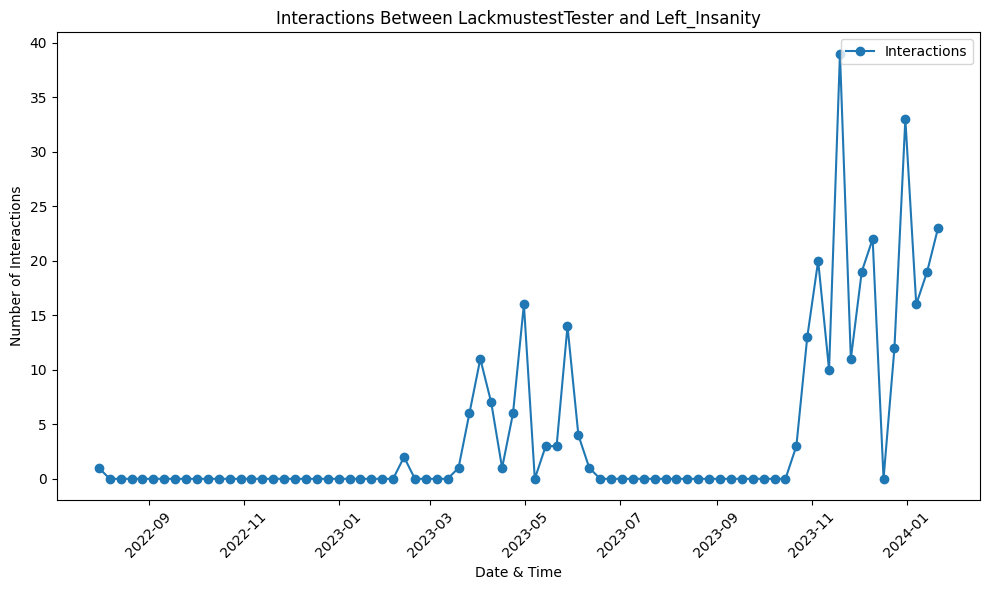

In [18]:
def plot_interactions(author1, author2, df, aggregation='none'):
    """
    Plots interactions over time between two specified authors.
    
    Parameters:
    - author1: The name of the first author.
    - author2: The name of the second author.
    - df: DataFrame containing the interactions data.
    - aggregation: The time frequency for aggregating data ('daily', 'weekly', 'monthly', 'none').
    """
    # Filter for interactions involving both authors, regardless of order
    df_filtered = df[((df['Author_1'] == author1) & (df['Author_2'] == author2)) |
                     ((df['Author_1'] == author2) & (df['Author_2'] == author1))]
    
    # Convert 'Date & Time' to datetime if not already
    df_filtered['Date & Time'] = pd.to_datetime(df_filtered['Date & Time'])
    
    # Set 'Date & Time' as the index
    df_filtered = df_filtered.set_index('Date & Time')
    
    # Aggregation
    if aggregation != 'none':
        # Define the resampling rule
        if aggregation == 'daily':
            rule = 'D'
        elif aggregation == 'weekly':
            rule = 'W'
        elif aggregation == 'monthly':
            rule = 'M'
        else:
            raise ValueError("Invalid aggregation value. Choose 'daily', 'weekly', 'monthly', or 'none'.")
        
        # Resample and count occurrences
        df_filtered = df_filtered.resample(rule).size().reset_index(name='Count')
    else:
        # If no aggregation, simply reset the index to get 'Date & Time' back as a column
        df_filtered.reset_index(inplace=True)
        df_filtered['Count'] = 1  # Add a count column for consistent plotting
    
    # Plotting
    plt.figure(figsize=(10, 6))
    
    if aggregation == 'none':
        # Plot each interaction as a point
        plt.scatter(df_filtered['Date & Time'], df_filtered['Count'], label='Interactions', alpha=0.7)
        plt.ylabel('Interactions')
    else:
        # Plot the aggregated data
        plt.plot(df_filtered['Date & Time'], df_filtered['Count'], marker='o', linestyle='-', label='Interactions')
        plt.ylabel('Number of Interactions')
    
    plt.title(f'Interactions Between {author1} and {author2}')
    plt.xlabel('Date & Time')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_interactions("LackmustestTester","Left_Insanity",df=df_all, aggregation='weekly')

C:\Users\Users\AppData\Local\Temp\ipykernel_11116\1005095871.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Date & Time'] = pd.to_datetime(df_filtered['Date & Time'])


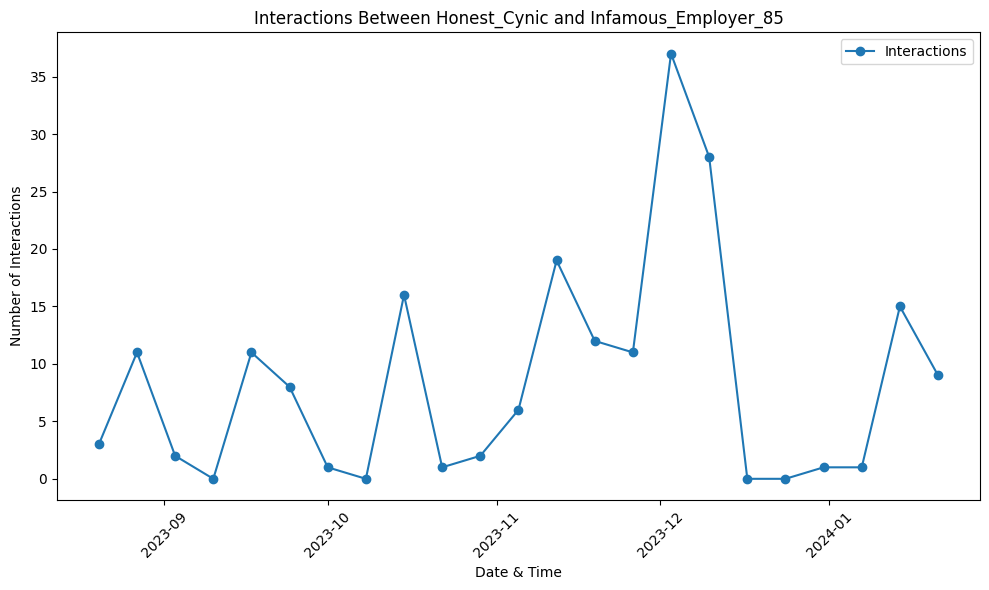

In [19]:
plot_interactions("Honest_Cynic","Infamous_Employer_85",df=df_all, aggregation='weekly')

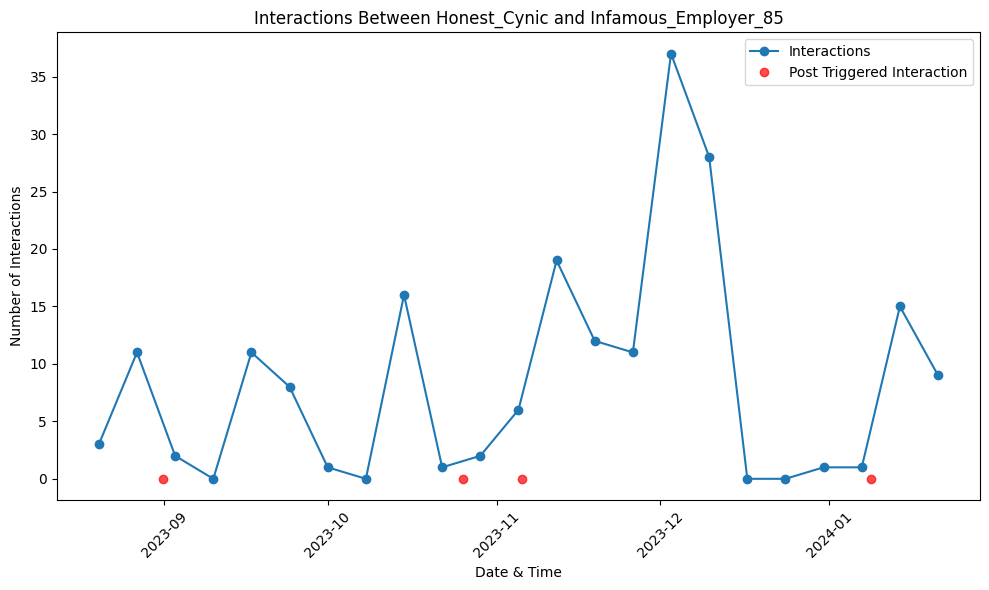

In [20]:
def plot_interactions_with_posts(author1, author2, df, aggregation='none'):
    """
    Plots interactions over time between two specified authors, with markers for specific posts that led to interactions.
    
    Parameters:
    - author1: The name of the first author.
    - author2: The name of the second author.
    - df: DataFrame containing the interactions data.
    - aggregation: The time frequency for aggregating data ('daily', 'weekly', 'monthly', 'none').
    """
    # Ensure 'Date & Time' is datetime
    df['Date & Time'] = pd.to_datetime(df['Date & Time'])
    
    # Filter interactions and posts
    interactions = df[((df['Author_1'] == author1) & (df['Author_2'] == author2)) | 
                      ((df['Author_1'] == author2) & (df['Author_2'] == author1))]
    
    # Filter only posts that led to interactions
    posts = interactions[interactions['Type'] == 'Post']
    
    # Set 'Date & Time' as the index for aggregation purposes
    interactions = interactions.set_index('Date & Time')

    # Aggregate if necessary
    if aggregation != 'none':
        rule = {'daily': 'D', 'weekly': 'W', 'monthly': 'M'}.get(aggregation)
        if not rule:
            raise ValueError("Invalid aggregation value. Choose 'daily', 'weekly', 'monthly', or 'none'.")
        
        interactions_count = interactions.resample(rule).size().reset_index(name='Count')
    else:
        interactions_count = interactions.reset_index()
        interactions_count['Count'] = 1  

    # Plotting
    plt.figure(figsize=(10, 6))

    # Plot interactions
    if aggregation != 'none':
        plt.plot(interactions_count['Date & Time'], interactions_count['Count'], marker='o', linestyle='-', label='Interactions')
    else:
        plt.scatter(interactions_count['Date & Time'], interactions_count['Count'], label='Interactions', alpha=0.7)

    # Highlight posts that led to interactions
    for _, row in posts.iterrows():
        plt.plot(row['Date & Time'], 0, 'ro', label='Post Triggered Interaction' if _ == posts.index[0] else "", alpha=0.7)  
    
    plt.title(f'Interactions Between {author1} and {author2}')
    plt.xlabel('Date & Time')
    plt.ylabel('Number of Interactions' if aggregation != 'none' else 'Interactions')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_interactions_with_posts("Honest_Cynic","Infamous_Employer_85",df=df_all, aggregation='weekly')
# plot_interactions_with_posts("LackmustestTester", "Left_Insanity", df=df_all, aggregation='weekly')

In [21]:
df_all

,Author_1,Author_2,Post ID,Date & Time,Subreddit,Type,Sorted Author Pair
0,Polyhedral_Media,MarcoYTVA,18w60ix,2024-01-01 20:36:33,FridaysForFuture,Post,"(MarcoYTVA, Polyhedral_Media)"
1,tkonicz,tkonicz,18jkfbc,2023-12-16 05:43:59,FridaysForFuture,Post,"(tkonicz, tkonicz)"
2,Monsteristbeste,tkonicz,18j3b0a,2023-12-15 15:58:11,FridaysForFuture,Post,"(Monsteristbeste, tkonicz)"
3,AccomplishedHotel383,Sendboobpics_please,18frxi8,2023-12-11 10:54:23,FridaysForFuture,Post,"(AccomplishedHotel383, Sendboobpics_please)"
4,AccomplishedHotel383,new_skool_hepcat,18frxi8,2023-12-11 10:54:23,FridaysForFuture,Post,"(AccomplishedHotel383, new_skool_hepcat)"
...,...,...,...,...,...,...,...
155850,GenericOfficeMan,_JohnJacob,tf0tj6,2022-03-18 00:27:01,ClimateCrisisCanada,Comment,"(GenericOfficeMan, _JohnJacob)"
155851,_JohnJacob,GenericOfficeMan,tf0tj6,2022-03-18 06:04:49,ClimateCrisisCanada,Comment,"(GenericOfficeMan, _JohnJacob)"
155852,GenericOfficeMan,_JohnJacob,tf0tj6,2022-03-18 20:13:00,ClimateCrisisCanada,Comment,"(GenericOfficeMan, _JohnJacob)"
155853,_JohnJacob,GenericOfficeMan,tf0tj6,2022-03-18 21:12:11,ClimateCrisisCanada,Comment,"(GenericOfficeMan, _JohnJacob)"


### Top contributions

In [22]:
def aggregate_interactions(df):

    # Count posts for each Author_1 in each Subreddit
    df1 = df[df['Type'] == 'Post'].drop_duplicates(subset=['Author_1','Post ID'])
    posts = df1.groupby(['Author_1', 'Subreddit']).size().reset_index(name='Posts').rename(columns={'Author_1': 'Author'})

    comments = df[df['Type'] == 'Comment'].groupby(['Author_2', 'Subreddit']).size().reset_index(name='Comments').rename(columns={'Author_2': 'Author'})

    # Merge posts and comments dataframes on Author and Subreddit
    merged = pd.merge(posts, comments, on=['Author', 'Subreddit'], how='outer').fillna(0)

    # Calculate total interactions as the sum of Posts and Comments
    merged['Total'] = merged['Posts'] + merged['Comments']


    return merged


def top_contributors(aggregated_df):
    # Group by Subreddit and sort within each group by Total interactions descending
    top_contributors = aggregated_df.sort_values(['Subreddit', 'Total'], ascending=[True, False]).groupby('Subreddit').head(10)
    return top_contributors

In [23]:
aggregated_df = aggregate_interactions(df_all)

# Get top 10 contributors for each subreddit
top_contributors_df = top_contributors(aggregated_df)

top_contributors_df


,Author,Subreddit,Posts,Comments,Total
2546,WaywardPatriot,ClimateActionPlan,37.0,294.0,331.0
3287,exprtcar,ClimateActionPlan,135.0,94.0,229.0
29334,upvotesthenrages,ClimateActionPlan,0.0,124.0,124.0
3661,kepler456,ClimateActionPlan,6.0,106.0,112.0
235,AutoModerator,ClimateActionPlan,107.0,0.0,107.0
...,...,...,...,...,...
506,Claire12335,greenpeace,1.0,0.0,1.0
638,Decent-Storage-4911,greenpeace,1.0,0.0,1.0
684,Disdreamed,greenpeace,1.0,0.0,1.0
1122,Hour-Log3499,greenpeace,1.0,0.0,1.0


In [24]:
s = top_contributors_df['Author'].value_counts()
s[s>1]

Author
ILikeNeurons         3
LackmustestTester    3
Better_Crazy_8669    2
fungussa             2
silence7             2
ttystikk             2
idspispopd           2
burtzev              2
NewyBluey            2
Tpaine63             2
MayonaiseRemover     2
Chibraltar_          2
upvotesthenrages     2
Name: count, dtype: int64

In [25]:
top_contributors_df[(top_contributors_df['Author']=="ILikeNeurons") | (top_contributors_df['Author']=="LackmustestTester")]

,Author,Subreddit,Posts,Comments,Total
1136,ILikeNeurons,ClimateActionPlan,16.0,85.0,101.0
1137,ILikeNeurons,ClimateOffensive,217.0,698.0,915.0
1369,LackmustestTester,FridaysForFuture,2.0,11.0,13.0
1370,LackmustestTester,climatechange,27.0,375.0,402.0
1138,ILikeNeurons,climatejustice,9.0,2.0,11.0
1371,LackmustestTester,climateskeptics,272.0,986.0,1258.0


These people are in TOP 10 active users in different subreddits.

## Construction de graphes

In [26]:
from datetime import datetime

In [27]:
def add_ISOYearWeek(df):
    # Convert 'Date & Time' to datetime format for easier manipulation
    df['Date & Time'] = pd.to_datetime(df['Date & Time'])

    # Segment data by week
    df['ISOYearWeek'] = df['Date & Time'].apply(lambda x: x.isocalendar()[0] * 100 + x.isocalendar()[1]).astype(str)
    return df

In [28]:
df = df_all.copy()

In [29]:
df = add_ISOYearWeek(df)
subreddit_name = "ClimateActionPlan"
subreddit_df = df[df['Subreddit'] == subreddit_name]

In [30]:
## Add publication date
df_temp = df_posts[['Post ID','Date & Time']].rename(columns={'Date & Time': "Date of Post"})
df = df.merge(df_temp,on="Post ID", how="left")
df

,Author_1,Author_2,Post ID,Date & Time,Subreddit,Type,Sorted Author Pair,ISOYearWeek,Date of Post
0,Polyhedral_Media,MarcoYTVA,18w60ix,2024-01-01 20:36:33,FridaysForFuture,Post,"(MarcoYTVA, Polyhedral_Media)",202401,2024-01-01 20:36:33
1,tkonicz,tkonicz,18jkfbc,2023-12-16 05:43:59,FridaysForFuture,Post,"(tkonicz, tkonicz)",202350,2023-12-16 05:43:59
2,Monsteristbeste,tkonicz,18j3b0a,2023-12-15 15:58:11,FridaysForFuture,Post,"(Monsteristbeste, tkonicz)",202350,2023-12-15 15:58:11
3,AccomplishedHotel383,Sendboobpics_please,18frxi8,2023-12-11 10:54:23,FridaysForFuture,Post,"(AccomplishedHotel383, Sendboobpics_please)",202350,2023-12-11 10:54:23
4,AccomplishedHotel383,new_skool_hepcat,18frxi8,2023-12-11 10:54:23,FridaysForFuture,Post,"(AccomplishedHotel383, new_skool_hepcat)",202350,2023-12-11 10:54:23
...,...,...,...,...,...,...,...,...,...
213577,GenericOfficeMan,_JohnJacob,tf0tj6,2022-03-18 00:27:01,ClimateCrisisCanada,Comment,"(GenericOfficeMan, _JohnJacob)",202211,2022-03-15 21:27:08
213578,_JohnJacob,GenericOfficeMan,tf0tj6,2022-03-18 06:04:49,ClimateCrisisCanada,Comment,"(GenericOfficeMan, _JohnJacob)",202211,2022-03-15 21:27:08
213579,GenericOfficeMan,_JohnJacob,tf0tj6,2022-03-18 20:13:00,ClimateCrisisCanada,Comment,"(GenericOfficeMan, _JohnJacob)",202211,2022-03-15 21:27:08
213580,_JohnJacob,GenericOfficeMan,tf0tj6,2022-03-18 21:12:11,ClimateCrisisCanada,Comment,"(GenericOfficeMan, _JohnJacob)",202211,2022-03-15 21:27:08


In [31]:
df['Date of Post'] = pd.to_datetime(df['Date of Post'])
df.dtypes

Author_1                      object
Author_2                      object
Post ID                       object
Date & Time           datetime64[ns]
Subreddit                     object
Type                          object
Sorted Author Pair            object
ISOYearWeek                   object
Date of Post          datetime64[ns]
dtype: object

In [32]:
# def create_interaction_graph(data):
#     G = nx.Graph()  # Use nx.DiGraph() for a directed graph if needed
#     for _, row in data.iterrows():
#         G.add_edge(row['Author_1'], row['Author_2'])
#     return G

##### Adding weights and make it a directed graph
def create_interaction_graph(data):
    G = nx.DiGraph()  # Create a directed graph
    # Iterate over each row in the DataFrame
    for _, row in data.iterrows():
        author_1 = row['Author_1']
        author_2 = row['Author_2']
        interaction_type = row['Type']  # Assume 'Type' column contains 'Post' or 'Comment'
        
        # Check if the edge already exists
        if G.has_edge(author_1, author_2):
            # If the edge exists, increment its weight
            G[author_1][author_2]['weight'] += 1
            # Optionally, update interaction type if needed
            # This is a simplistic approach; in reality, you might want to handle multiple interactions differently
            G[author_1][author_2]['type'] = interaction_type
        else:
            # If the edge doesn't exist, add it with weight 1 and the interaction type
            G.add_edge(author_2, author_1, weight=1, type=interaction_type)
    return G

# Create a graph for each 'YearWeek'
weekly_graphs = {}
for year_week in subreddit_df['ISOYearWeek'].unique():
    week_data = subreddit_df[subreddit_df['ISOYearWeek'] == year_week]
    weekly_graphs[year_week] = create_interaction_graph(week_data)


In [33]:
def get_top_n_edges(graph, n=10):
    # Get all edges with their weights
    edges = graph.edges(data=True)
    
    # Sort edges by weight in descending order
    sorted_edges = sorted(edges, key=lambda x: x[2]['weight'], reverse=True)
    
    # Return the top n edges
    return sorted_edges[:n]

# Get the top 10 edges from the graph for week 202350
top_10_edges = get_top_n_edges(weekly_graphs['202350'], n=10)

# Print the top 10 edges
for edge in top_10_edges:
    print(edge)


get_top_n_edges(weekly_graphs['202350'], n=10)

('Tech_Philosophy', 'YaleE360', {'weight': 1, 'type': 'Post'})
('JimJM2', 'YaleE360', {'weight': 1, 'type': 'Post'})
('Rochereau', 'Jaadmaan123', {'weight': 1, 'type': 'Post'})


[('Tech_Philosophy', 'YaleE360', {'weight': 1, 'type': 'Post'}),
 ('JimJM2', 'YaleE360', {'weight': 1, 'type': 'Post'}),
 ('Rochereau', 'Jaadmaan123', {'weight': 1, 'type': 'Post'})]

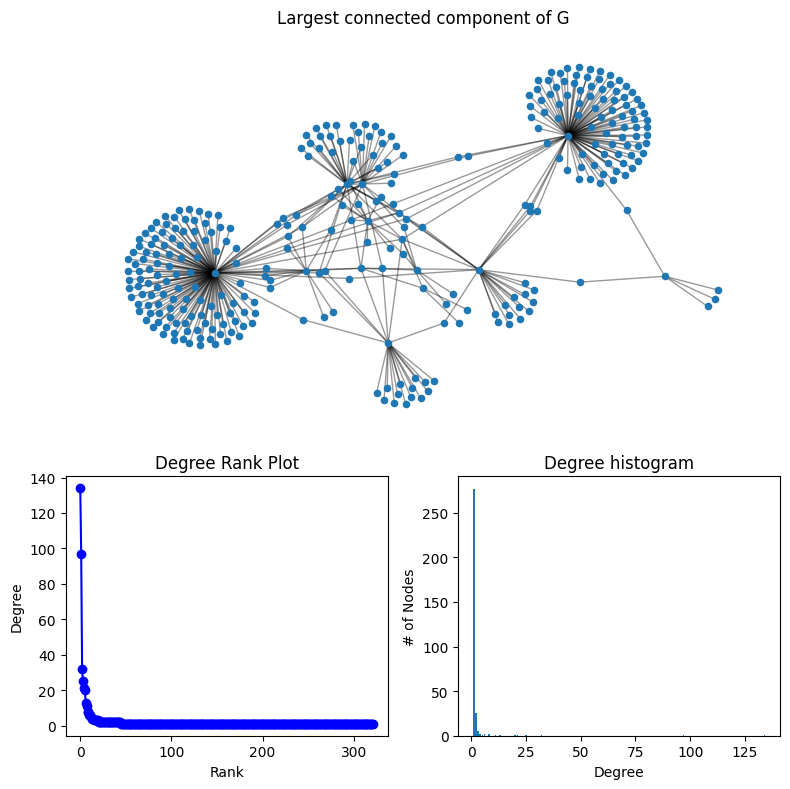

In [34]:
import networkx as nx


def plot_graph_between(dic,start_week,endweek):
    new_dic={}
    start_year = int(start_week[:4])
    end_year = int(endweek[:4])
    start_week = int(start_week[4:])
    end_week = int(endweek[4:])
    for year in range(start_year,end_year+1):
        for week in range(start_week,end_week+1):
            new_dic[week]=dic[str(year)+str(week)]
    return new_dic




G=nx.Graph(plot_graph_between(weekly_graphs,"202340","202350"))
degree_sequence = sorted((d for n, d in G.degree()), reverse=True)
dmax = max(degree_sequence)

fig = plt.figure("Degree of a random graph", figsize=(8, 8))
# Create a gridspec for adding subplots of different sizes
axgrid = fig.add_gridspec(5, 4)

ax0 = fig.add_subplot(axgrid[0:3, :])
Gcc = G.subgraph(sorted(nx.connected_components(G), key=len, reverse=True)[0])
pos = nx.spring_layout(Gcc, seed=10396953)
nx.draw_networkx_nodes(Gcc, pos, ax=ax0, node_size=20)
nx.draw_networkx_edges(Gcc, pos, ax=ax0, alpha=0.4)
ax0.set_title("Largest connected component of G")
ax0.set_axis_off()

ax1 = fig.add_subplot(axgrid[3:, :2])
ax1.plot(degree_sequence, "b-", marker="o")
ax1.set_title("Degree Rank Plot")
ax1.set_ylabel("Degree")
ax1.set_xlabel("Rank")

ax2 = fig.add_subplot(axgrid[3:, 2:])
ax2.bar(*np.unique(degree_sequence, return_counts=True))
ax2.set_title("Degree histogram")
ax2.set_xlabel("Degree")
ax2.set_ylabel("# of Nodes")

fig.tight_layout()
plt.show()

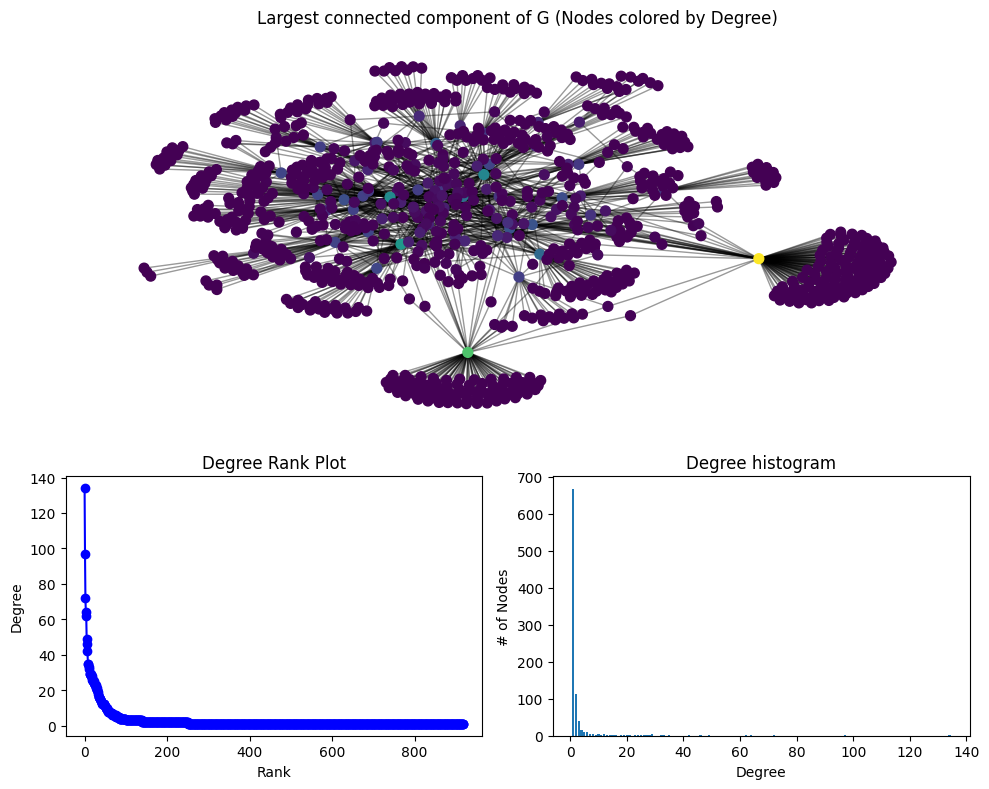

In [43]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def plot_graph_between(dic,start_week,endweek):
    new_dic={}
    start_year = int(start_week[:4])
    end_year = int(endweek[:4])
    start_week = int(start_week[4:])
    end_week = int(endweek[4:])
    time = {"year":start_year, "week":start_week}
    while time["week"]<end_week or time["year"]<end_year:
        str_time = "" + str(time["year"]) 
        if time["week"]<10:
            str_time += "0" + str(time["week"])
        else:
            str_time += str(time["week"])
        new_dic[str_time]=dic[str_time]
        time["week"]+=1
        if time["week"]==53:
            time["week"]=1
            time["year"]+=1
    return nx.Graph(new_dic)



G=plot_graph_between(weekly_graphs,"202302","202403")
degree_sequence = sorted((d for n, d in G.degree()), reverse=True)
dmax = max(degree_sequence)

fig = plt.figure("Degree of a random graph", figsize=(10, 8))
# Create a gridspec for adding subplots of different sizes
axgrid = fig.add_gridspec(5, 4)

ax0 = fig.add_subplot(axgrid[0:3, :])

# Ensure there's a connected component to draw
if G.number_of_nodes() > 0:
    # Get largest connected component
    Gcc = G.subgraph(sorted(nx.connected_components(G), key=len, reverse=True)[0])
    pos = nx.spring_layout(Gcc, seed=10396953)

    # Get node degrees for coloring
    node_degrees = dict(Gcc.degree())
    # Normalize degrees to a range for colormap
    if len(node_degrees) > 0 and max(node_degrees.values()) > 0:
        # Create a colormap based on degree
        cmap = plt.cm.viridis
        # Get colors for nodes based on their normalized degree
        # Smallest degree to 0, largest to 1 for colormap scaling
        min_degree = min(node_degrees.values())
        max_degree = max(node_degrees.values())
        if min_degree == max_degree: # Handle case where all nodes have the same degree
            node_colors = ['blue'] * len(Gcc.nodes())
        else:
            node_colors = [cmap((degree - min_degree) / (max_degree - min_degree)) for degree in node_degrees.values()]

        nx.draw_networkx_nodes(Gcc, pos, ax=ax0, node_size=50, node_color=node_colors)
    else:
        nx.draw_networkx_nodes(Gcc, pos, ax=ax0, node_size=50, node_color='lightblue') # Default if no degrees or single node

    nx.draw_networkx_edges(Gcc, pos, ax=ax0, alpha=0.4)
    #nx.draw_networkx_labels(Gcc, pos, font_size=6, font_family='sans-serif') # Optional: add labels if not too crowded

    ax0.set_title("Largest connected component of G (Nodes colored by Degree)")
else:
    ax0.set_title("No nodes to display in the largest connected component.")

ax0.set_axis_off()

ax1 = fig.add_subplot(axgrid[3:, :2])
if len(degree_sequence) > 0:
    ax1.plot(degree_sequence, "b-", marker="o")
    ax1.set_title("Degree Rank Plot")
    ax1.set_ylabel("Degree")
    ax1.set_xlabel("Rank")
else:
    ax1.set_title("No degrees to plot.")

ax2 = fig.add_subplot(axgrid[3:, 2:])
if len(degree_sequence) > 0:
    ax2.bar(*np.unique(degree_sequence, return_counts=True))
    ax2.set_title("Degree histogram")
    ax2.set_xlabel("Degree")
    ax2.set_ylabel("# of Nodes")
else:
    ax2.set_title("No degrees to plot.")

fig.tight_layout()
plt.show()

Feel free to use dynamics (sequence of graphs) or not, to combine graph-based KPIs with others, or not. Be innovative!